Final Output Voltage: 4.630917209858034


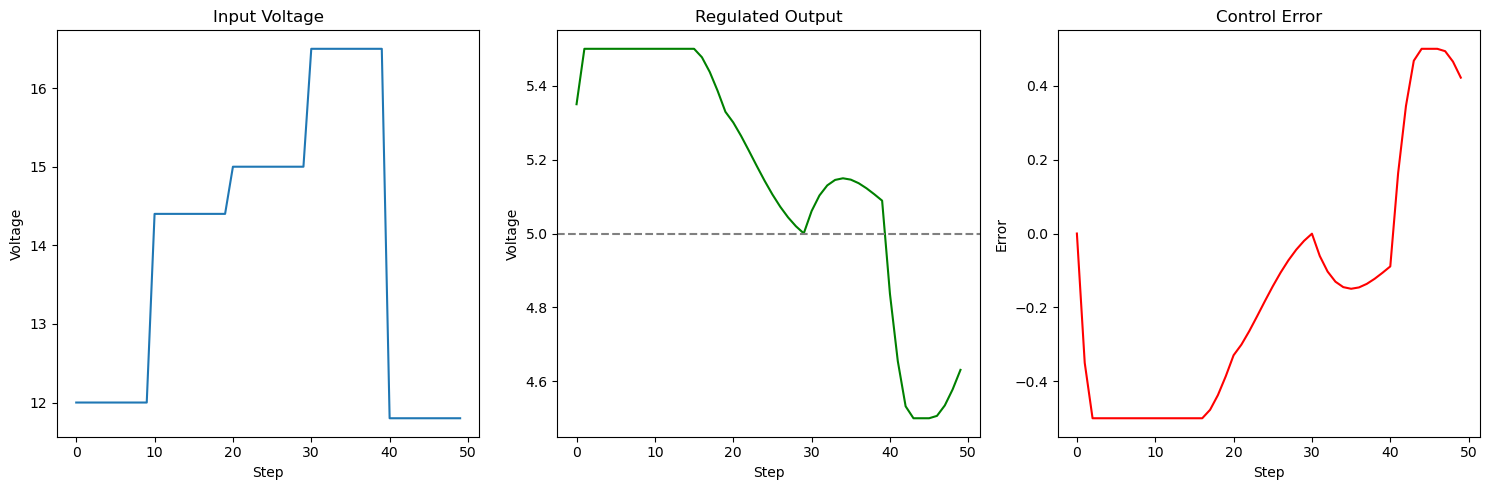

In [1]:
# -*- coding: utf-8 -*-
"""
Improved Smart Voltage Regulator with PID Control
"""

import numpy as np
import matplotlib.pyplot as plt

class SmartVoltageRegulator:
    def __init__(self, target_voltage=5.0, tolerance=0.5,
                 kp=0.2, ki=0.05, kd=0.01):
        """
        PID-based voltage regulator
        
        Args:
            target_voltage (float): Desired output voltage
            tolerance (float): Acceptable voltage variation
            kp, ki, kd (float): PID gains
        """
        self.target_voltage = target_voltage
        self.tolerance_range = tolerance
        
        # PID parameters
        self.kp = kp
        self.ki = ki
        self.kd = kd
        
        # State variables
        self.integral = 0
        self.prev_error = 0
        self.output_voltage = target_voltage  # start at target
        
        # Performance tracking
        self.voltage_history = []
        self.output_history = []
        self.error_history = []

    def regulate_voltage(self, input_voltage):
        """
        Perform one regulation step
        """
        # Error based on current output (feedback!)
        error = self.target_voltage - self.output_voltage
        
        # PID calculations
        self.integral += error
        derivative = error - self.prev_error
        
        correction = (
            self.kp * error +
            self.ki * self.integral +
            self.kd * derivative
        )
        
        # Update output voltage
        self.output_voltage += correction
        
        # Optional: simulate influence of input voltage (disturbance)
        # You can scale this effect if desired
        disturbance = 0.05 * (input_voltage - self.output_voltage)
        self.output_voltage += disturbance
        
        # Clamp to tolerance range
        self.output_voltage = np.clip(
            self.output_voltage,
            self.target_voltage - self.tolerance_range,
            self.target_voltage + self.tolerance_range
        )
        
        # Save state
        self.prev_error = error
        
        # Track metrics
        self.voltage_history.append(input_voltage)
        self.output_history.append(self.output_voltage)
        self.error_history.append(error)
        
        return self.output_voltage

    def simulate_voltage_variations(self, input_voltages, steps_per_input=10):
        """
        Run multiple iterations per input to simulate stabilization
        """
        outputs = []
        
        for v in input_voltages:
            for _ in range(steps_per_input):
                outputs.append(self.regulate_voltage(v))
        
        return outputs

    def plot_voltage_regulation(self):
        plt.figure(figsize=(15, 5))
        
        plt.subplot(131)
        plt.plot(self.voltage_history, label='Input Voltage')
        plt.title('Input Voltage')
        plt.xlabel('Step')
        plt.ylabel('Voltage')
        
        plt.subplot(132)
        plt.plot(self.output_history, label='Output Voltage', color='green')
        plt.axhline(self.target_voltage, linestyle='--', color='gray')
        plt.title('Regulated Output')
        plt.xlabel('Step')
        plt.ylabel('Voltage')
        
        plt.subplot(133)
        plt.plot(self.error_history, label='Error', color='red')
        plt.title('Control Error')
        plt.xlabel('Step')
        plt.ylabel('Error')
        
        plt.tight_layout()
        plt.show()


# ✅ Usage example
regulator = SmartVoltageRegulator()

input_voltages = [12.0, 14.4, 15.0, 16.5, 11.8]

regulated_voltages = regulator.simulate_voltage_variations(input_voltages)

print("Final Output Voltage:", regulated_voltages[-1])

regulator.plot_voltage_regulation()

Final Efficiency: 95.0 %


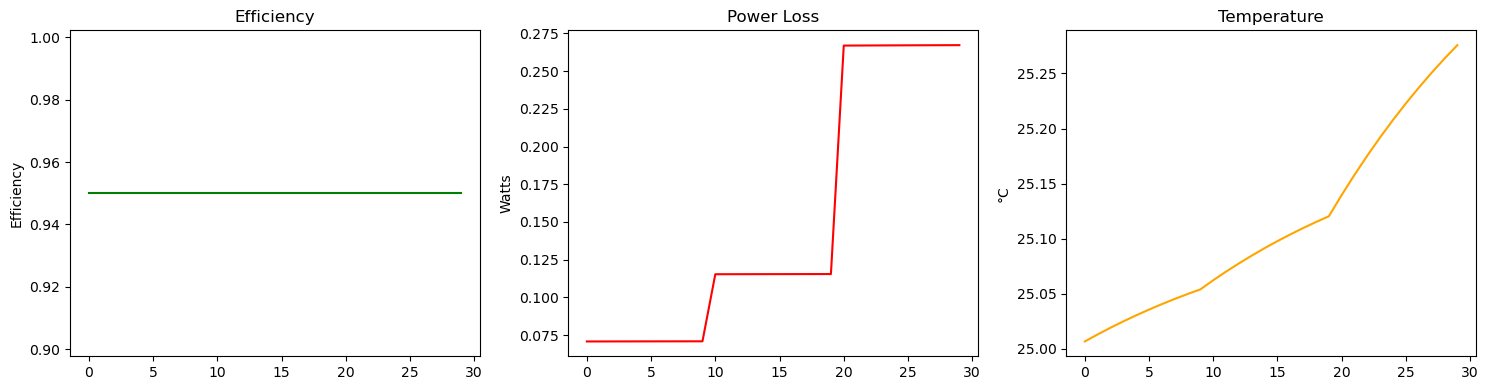

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class EfficiencyOptimizer:
    def __init__(self, target_voltage=5.0):
        self.target_voltage = target_voltage
        
        # Tracking
        self.efficiency_history = []
        self.loss_history = []
        self.temperature_history = []
        
        # Thermal state
        self.temperature = 25  # °C (ambient start)

    def optimize_power_conversion(self, input_voltage, load_current):
        """
        More realistic efficiency estimation based on power + losses
        """
        # Output power
        output_power = self.target_voltage * load_current
        
        # --- Loss Models ---
        
        # 1. Conduction loss (∝ I²)
        conduction_loss = 0.05 * (load_current ** 2)
        
        # 2. Switching loss (∝ Vin mismatch)
        voltage_ratio = self.target_voltage / input_voltage
        switching_loss = 0.1 * (1 - voltage_ratio)
        
        # 3. Thermal loss (depends on temperature rise)
        thermal_penalty = max(0, (self.temperature - 25) * 0.002)
        
        # Total loss
        total_loss = conduction_loss + switching_loss + thermal_penalty
        
        # Input power = output + loss
        input_power = output_power + total_loss
        
        # Efficiency
        efficiency = output_power / input_power
        
        # Clamp realistic range
        efficiency = np.clip(efficiency, 0.7, 0.95)
        
        # --- Thermal Update (dynamic behavior) ---
        power_dissipation = total_loss
        self.temperature += 0.1 * power_dissipation   # heating
        self.temperature -= 0.05 * (self.temperature - 25)  # cooling
        
        # --- Tracking ---
        self.efficiency_history.append(efficiency)
        self.loss_history.append(total_loss)
        self.temperature_history.append(self.temperature)
        
        return efficiency

    def simulate(self, scenarios, steps_per_case=10):
        results = []
        for vin, current in scenarios:
            for _ in range(steps_per_case):
                eff = self.optimize_power_conversion(vin, current)
                results.append(eff)
        return results

    def plot(self):
        plt.figure(figsize=(15, 4))
        
        plt.subplot(131)
        plt.plot(self.efficiency_history, color='green')
        plt.title('Efficiency')
        plt.ylabel('Efficiency')
        
        plt.subplot(132)
        plt.plot(self.loss_history, color='red')
        plt.title('Power Loss')
        plt.ylabel('Watts')
        
        plt.subplot(133)
        plt.plot(self.temperature_history, color='orange')
        plt.title('Temperature')
        plt.ylabel('°C')
        
        plt.tight_layout()
        plt.show()


# ✅ Usage
optimizer = EfficiencyOptimizer()

scenarios = [
    (12.0, 0.5),
    (14.4, 1.0),
    (15.0, 2.0)
]

results = optimizer.simulate(scenarios)

print("Final Efficiency:", results[-1] * 100, "%")

optimizer.plot()